In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = {
    'Study_Hours': [
        2, 3, 4, 5, 6, 7, 8, 9,
        1, 2, 3, 4, 5, 6, 7, 8,
        2, 4, 6, 8, 3, 5, 7, 9,
        1, 3, 5, 7, 4, 6, 8, 10
    ],

    'Attendance': [
        60, 65, 70, 75, 80, 85, 90, 95,
        55, 62, 68, 74, 82, 88, 92, 96,
        58, 72, 84, 94, 66, 78, 86, 98,
        52, 64, 76, 89, 70, 83, 91, 99
    ],

    'Previous_Marks': [
        45, 50, 55, 60, 65, 70, 75, 80,
        40, 48, 52, 58, 67, 72, 78, 85,
        42, 57, 68, 82, 49, 63, 73, 88,
        38, 46, 61, 77, 54, 69, 81, 90
    ],

    # 0 = Fail, 1 = Pass
    'Pass': [
        0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
print("OUR DATASET")
print("=" * 50)
df.head()

OUR DATASET


,Study_Hours,Attendance,Previous_Marks,Pass
0,2,60,45,0
1,3,65,50,0
2,4,70,55,0
3,5,75,60,1
4,6,80,65,1


In [117]:
X = df[
    [
        'Study_Hours',
        'Attendance',
        'Previous_Marks'
    ]
]

y = df['Pass']

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (24, 3)
Testing data : (8, 3)


In [119]:
# ============================================================
# BAGGING
# ============================================================

print("\n")
print("=" * 50)
print("BAGGING CLASSIFICATION")
print("=" * 50)


# Create Decision Tree
decision_tree = DecisionTreeClassifier(
    random_state=42
)


# Create Bagging model
bagging_model = BaggingClassifier(
    estimator=decision_tree,
    n_estimators=50,
    random_state=42
)


# Train model
bagging_model.fit(X_train, y_train)


# Prediction
y_pred_bagging = bagging_model.predict(X_test)


# Accuracy
bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

print("\nBagging Accuracy:")
print(bagging_accuracy)


# Classification Report
print("\nBagging Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_bagging
    )
)


# Confusion Matrix
print("Bagging Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_bagging
    )
)



BAGGING CLASSIFICATION

Bagging Accuracy:
1.0

Bagging Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Bagging Confusion Matrix:
[[3 0]
 [0 5]]


In [120]:
# ============================================================
# BOOSTING
# ============================================================

print("\n")
print("=" * 50)
print("BOOSTING CLASSIFICATION")
print("=" * 50)


# Create AdaBoost model
boosting_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)


# Train model
boosting_model.fit(X_train, y_train)


# Prediction
y_pred_boosting = boosting_model.predict(X_test)


# Accuracy
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)

print("\nBoosting Accuracy:")
print(boosting_accuracy)


# Classification Report
print("\nBoosting Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_boosting
    )
)


# Confusion Matrix
print("Boosting Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_boosting
    )
)



BOOSTING CLASSIFICATION

Boosting Accuracy:
1.0

Boosting Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Boosting Confusion Matrix:
[[3 0]
 [0 5]]


In [121]:
# ============================================================
# COMPARISON
# ============================================================

print("\n")
print("=" * 50)
print("BAGGING VS BOOSTING")
print("=" * 50)

print("Bagging Accuracy  :", bagging_accuracy)
print("Boosting Accuracy :", boosting_accuracy)



BAGGING VS BOOSTING
Bagging Accuracy  : 1.0
Boosting Accuracy : 1.0


In [122]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [123]:
iris = load_iris()

X = iris.data
y = iris.target

# Create DataFrame
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df['target'] = y

print("IRIS DATASET")
print("=" * 50)

display(df.head())

IRIS DATASET


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [124]:
print("Dataset Shape:", df.shape)

print("\nTarget Classes:")
print(iris.target_names)

print("\nClass Distribution:")
print(df['target'].value_counts())

Dataset Shape: (150, 5)

Target Classes:
['setosa' 'versicolor' 'virginica']

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("\n")
print("=" * 60)
print("BAGGING CLASSIFICATION")
print("=" * 60)


Training samples: 120
Testing samples : 30


BAGGING CLASSIFICATION


In [126]:
# ============================================================
# STEP 8: BAGGING CLASSIFIER
# ============================================================

# Base Decision Tree
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Bagging model
bagging_model = BaggingClassifier(
    estimator=decision_tree,
    n_estimators=50,
    random_state=42
)

# Train
bagging_model.fit(X_train, y_train)

# Predict
y_pred_bagging = bagging_model.predict(X_test)


bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

print("\nBagging Accuracy:")
print(bagging_accuracy)

print("\nBagging Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=iris.target_names
    )
)

print("Bagging Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_bagging
    )
)


Bagging Accuracy:
0.9666666666666667

Bagging Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Bagging Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [127]:
# ============================================================
# BOOSTING CLASSIFIER
# ============================================================

print("\n")
print("=" * 60)
print("BOOSTING CLASSIFICATION")
print("=" * 60)

# AdaBoost model
boosting_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)

# Train
boosting_model.fit(X_train, y_train)

# Predict
y_pred_boosting = boosting_model.predict(X_test)
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)

print("\nBoosting Accuracy:")
print(boosting_accuracy)

print("\nBoosting Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_boosting,
        target_names=iris.target_names
    )
)

print("Boosting Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_boosting
    )
)



BOOSTING CLASSIFICATION

Boosting Accuracy:
0.9

Boosting Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Boosting Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


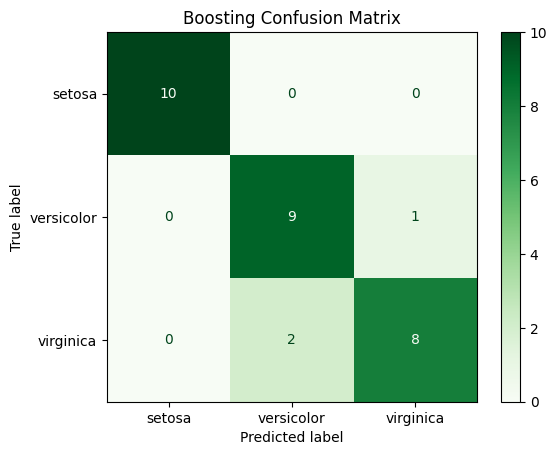



BAGGING VS BOOSTING COMPARISON
Bagging Accuracy  : 0.9666666666666667
Boosting Accuracy : 0.9


In [128]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_boosting,
    display_labels=iris.target_names,
    cmap='Greens'
)

plt.title("Boosting Confusion Matrix")
plt.show()

print("\n")
print("=" * 60)
print("BAGGING VS BOOSTING COMPARISON")
print("=" * 60)

print("Bagging Accuracy  :", bagging_accuracy)
print("Boosting Accuracy :", boosting_accuracy)

In [129]:
comparison = pd.DataFrame({
    'Model': [
        'Bagging',
        'Boosting'
    ],
    'Accuracy': [
        bagging_accuracy,
        boosting_accuracy
    ]
})

print("\nComparison Table:")
display(comparison)


Comparison Table:


,Model,Accuracy
0,Bagging,0.966667
1,Boosting,0.900000


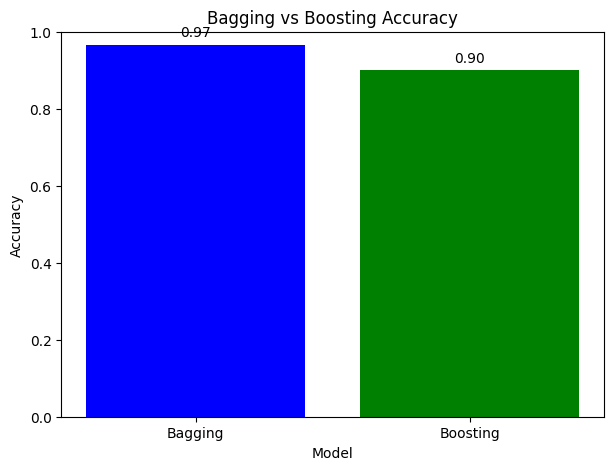

In [130]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy'],
    color=['blue', 'green']
)

plt.title("Bagging vs Boosting Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(comparison['Accuracy']):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha='center'
    )

plt.show()